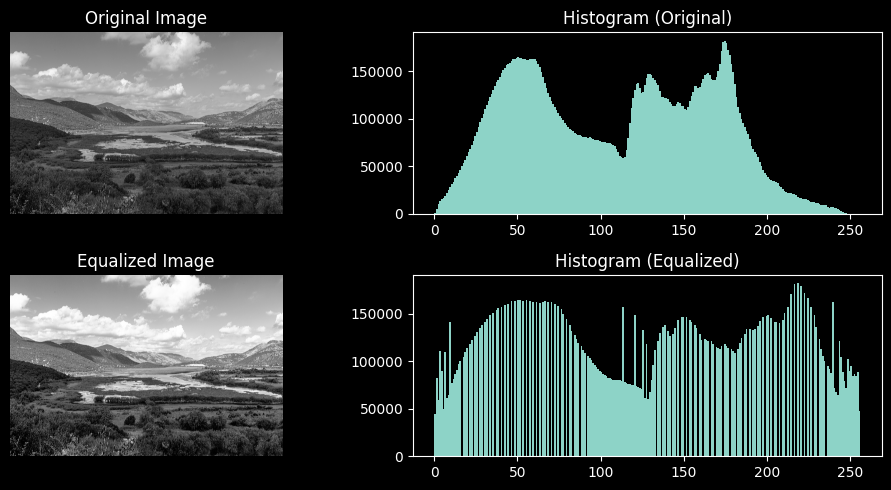

In [4]:
# Task 1
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('images/test_image.jpg', cv2.IMREAD_GRAYSCALE)

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.hist(image.ravel(), bins=256, range=[0, 256])
plt.title('Histogram (Original)')

plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.hist(equalized_image.ravel(), bins=256, range=[0, 256])
plt.title('Histogram (Equalized)')

plt.tight_layout()
plt.show()

# Histogram equalization enhances contrast by redistributing pixel intensities across the full dynamic range. It is especially effective in low-light or poorly exposed images, where intensity values are clustered in a narrow range.

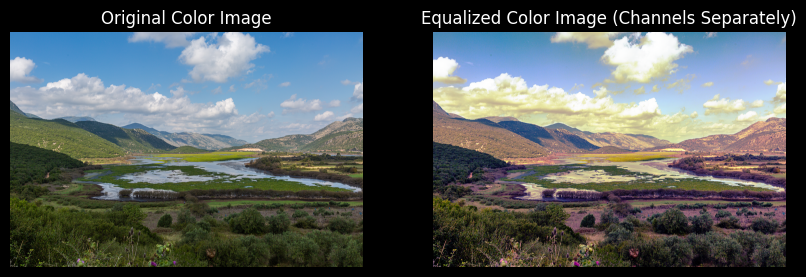

In [7]:
#Task 2
import cv2
import matplotlib.pyplot as plt

color_image = cv2.imread('images/test_image.jpg')

(b, g, r) = cv2.split(color_image)

equalized_b = cv2.equalizeHist(b)
equalized_g = cv2.equalizeHist(g)
equalized_r = cv2.equalizeHist(r)

equalized_color_image = cv2.merge([equalized_b, equalized_g, equalized_r])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(equalized_color_image, cv2.COLOR_BGR2RGB))
plt.title('Equalized Color Image (Channels Separately)')
plt.axis('off')
plt.show()

# Applying histogram equalization separately to the RGB channels increases contrast, but it may distort the color balance. Since each channel is stretched independently, the relative proportions of Red, Green, and Blue intensities change, leading to unnatural or exaggerated colors.

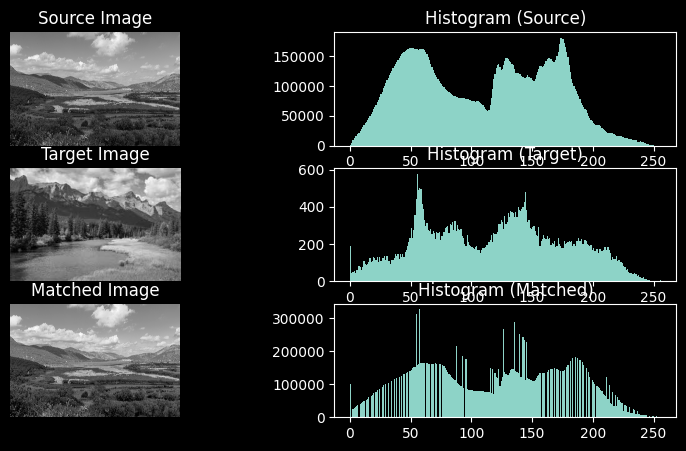

In [10]:
#Task 3
import cv2
import numpy as np
from skimage import exposure
import matplotlib.pyplot as plt

image_source = cv2.imread('images/test_image.jpg', cv2.IMREAD_GRAYSCALE)
image_target = cv2.imread('images/test_image_2.jpeg', cv2.IMREAD_GRAYSCALE)

matched_image = exposure.match_histograms(image_source, image_target)

plt.figure(figsize=(15, 5))
plt.subplot(3, 3, 1)
plt.imshow(image_source, cmap='gray')
plt.title('Source Image')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.hist(image_source.ravel(), bins=256, range=[0, 256])
plt.title('Histogram (Source)')

plt.subplot(3, 3, 4)
plt.imshow(image_target, cmap='gray')
plt.title('Target Image')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.hist(image_target.ravel(), bins=256, range=[0,256])
plt.title('Histogram (Target)')

plt.subplot(3, 3, 7)
plt.imshow(matched_image, cmap='gray')
plt.title('Matched Image')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.hist(matched_image.ravel(), bins=256, range=[0,256])
plt.title('Histogram (Matched)')

plt.show()

# Histogram matching modifies the pixel intensity distribution of the source image so that it resembles the histogram of the target image. As a result, the overall brightness and contrast of the source image change to reflect the lighting characteristics of the target image. If the target image is brighter, the matched image becomes brighter; if the target has higher contrast, the matched image gains stronger intensity differences. This technique effectively transfers the tonal style of the target image to the source image.

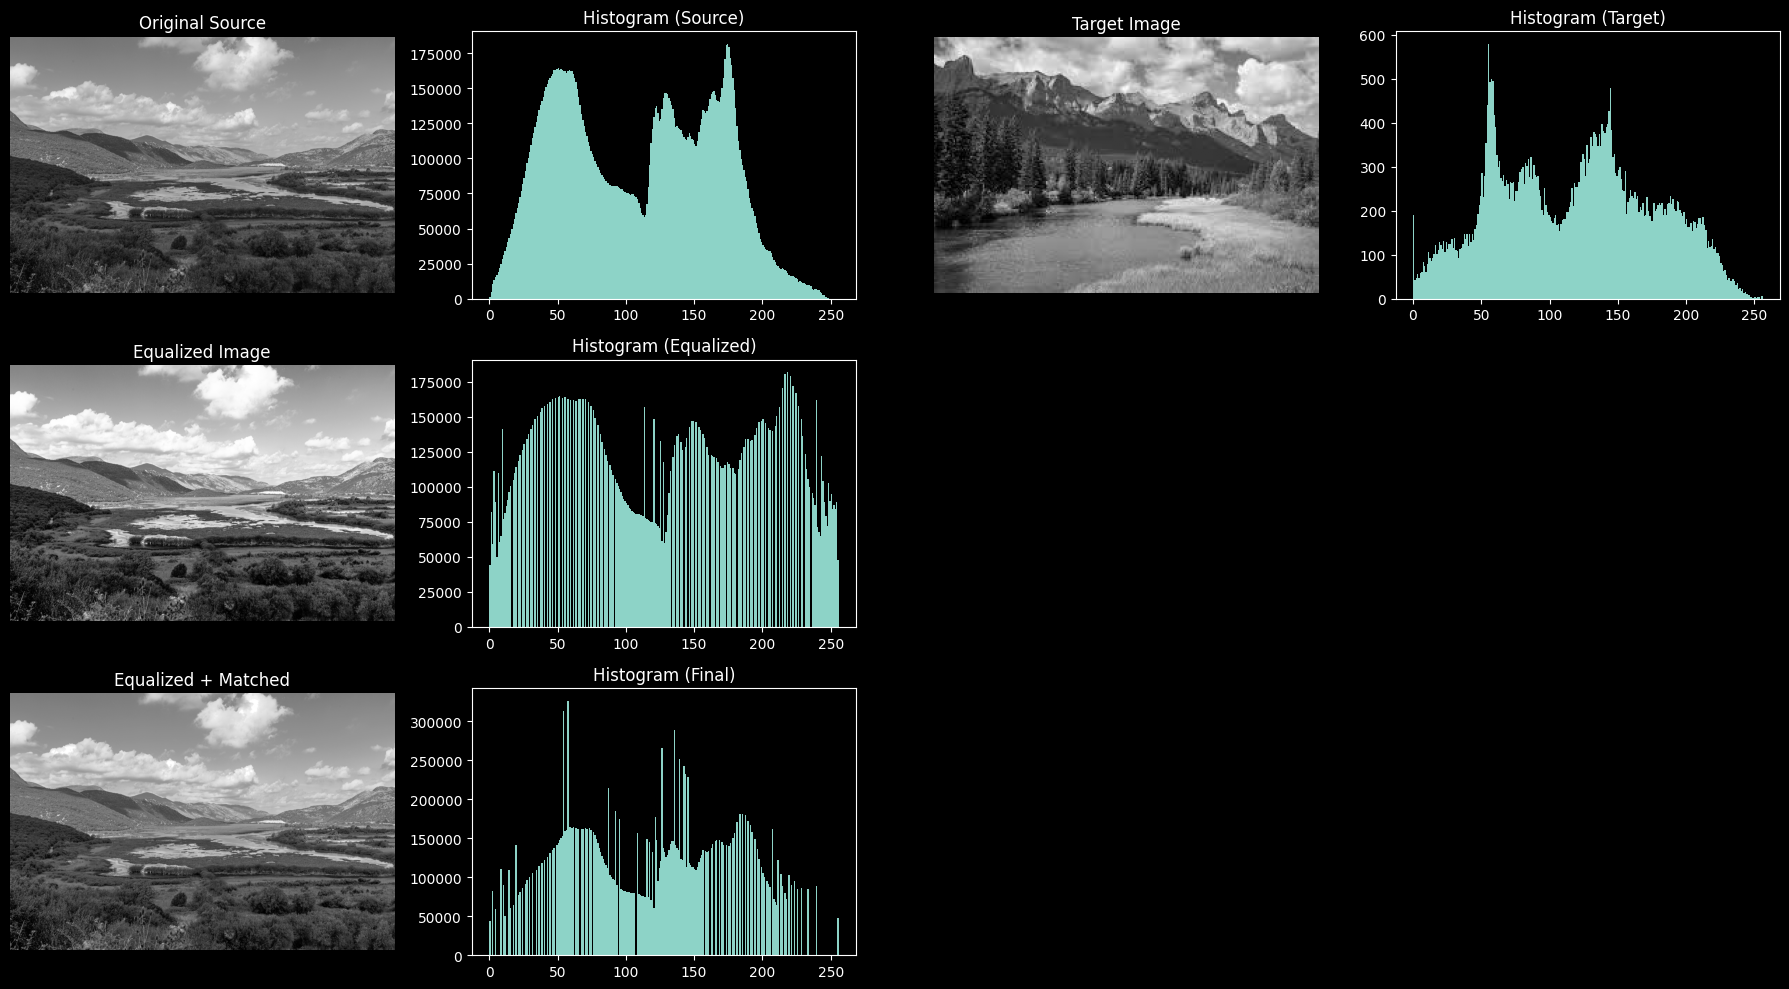

In [13]:
#Task 4
import cv2
import numpy as np
from skimage import exposure
import matplotlib.pyplot as plt

image_source = cv2.imread('images/test_image.jpg', cv2.IMREAD_GRAYSCALE)
image_target = cv2.imread('images/test_image_2.jpeg', cv2.IMREAD_GRAYSCALE)

if image_source is None:
    print("Source image not found. Check the path.")
if image_target is None:
    print("Target image not found. Check the path.")

equalized_image = cv2.equalizeHist(image_source)

matched_image = exposure.match_histograms(equalized_image, image_target)

plt.figure(figsize=(18, 10))

plt.subplot(3,4,1)
plt.imshow(image_source, cmap='gray')
plt.title('Original Source')
plt.axis('off')

plt.subplot(3,4,2)
plt.hist(image_source.ravel(), bins=256, range=[0,256])
plt.title('Histogram (Source)')

plt.subplot(3,4,3)
plt.imshow(image_target, cmap='gray')
plt.title('Target Image')
plt.axis('off')

plt.subplot(3,4,4)
plt.hist(image_target.ravel(), bins=256, range=[0,256])
plt.title('Histogram (Target)')

plt.subplot(3,4,5)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(3,4,6)
plt.hist(equalized_image.ravel(), bins=256, range=[0,256])
plt.title('Histogram (Equalized)')

plt.subplot(3,4,9)
plt.imshow(matched_image, cmap='gray')
plt.title('Equalized + Matched')
plt.axis('off')

plt.subplot(3,4,10)
plt.hist(matched_image.ravel(), bins=256, range=[0,256])
plt.title('Histogram (Final)')

plt.tight_layout()
plt.show()